<a href="https://colab.research.google.com/github/PedroConst/EQE-358-Metodos-Numericos/blob/main/Lab/Lab_05_Tanque_Encamisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 05 – Tanque Encamisado**

## Objetivos
- Introduzir balanços de energia transientes
- Definir equações diferenciais em Python
- Resolver um problema de valor inicial em Python usando Métodos de Euler Explícito e Implícito
- Analizar acurácia e instabilidade numérica

---

## Contexto

Em muitos processos industriais — nas indústrias química, petroquímica, farmacêutica e de alimentos — é necessário aquecer líquidos armazenados em tanques para atingir condições adequadas de operação. O aquecimento pode ser necessário, por exemplo, para reduzir a viscosidade de um fluido, acelerar uma reação química, dissolver sólidos ou preparar correntes de processo para etapas posteriores.

Uma forma muito comum de realizar esse aquecimento é por meio de camisas térmicas aquecidas a vapor. Nesse tipo de equipamento, o vapor circula na camisa externa do tanque e condensa ao transferir calor para o líquido no interior do vaso. Como o vapor saturado permanece aproximadamente a temperatura constante durante a condensação, a taxa de transferência de calor pode ser modelada como proporcional à diferença de temperatura entre o vapor e o líquido no tanque.

Link para vídeo: [Tanque Encamisado](https://youtu.be/w_YUeoGFKYg?si=a6veu0-EOLFuJNNR)

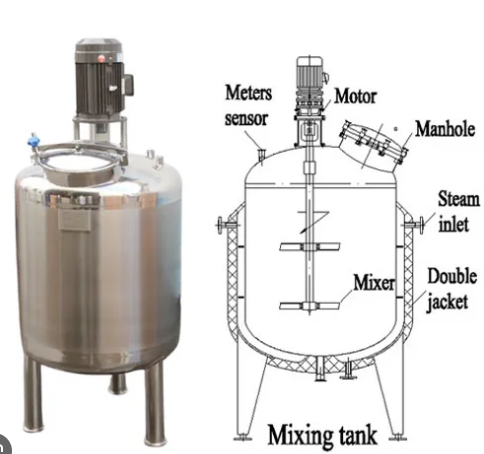

## **Modelo Matemático**

Balanço de Energia
$$
\rho\ VC_p\frac{dT}{dt}=UA_s(T_v-T)-UA_p\left(T-T_{amb}\right)
\tag{1}
$$

##**🔹 Passo 1 – Importar bibliotecas**

In [ ]:
import ...
import ...

##**🔹 Passo 2 – Inserir Dados do Problema**

In [ ]:
V = ...                 # volume (m3)
rho = ...              # densidade (kg/m3)
Cp = ...               # capacidade calorífica (J/kg K)

UA_s = ...            # transferência vapor-tanque (W/K)
UA_p = ...              # perdas para ambiente (W/K)

Tv = ...                # temperatura do vapor (°C)
Tamb = ...               # temperatura ambiente (°C)
T0 = ...                 # temperatura inicial (°C)

##**🔹 Passo 3 – Definir Equação Diferencial**

In [ ]:
# Definir a função f(t,y)
def getf(t,T):
    # dT/dt = a - bT
    a = ...
    b = ...
    f = ...
    return f

##**🔹 Passo 4 – Definir Solução Analítica**

In [ ]:
# Definir a solução analítica y(t)
def T_exato(t):

    a = ...
    b = ...
    Tss = ...
    tau = ...

    print("Constante de tempo do sistema (s):", tau)
    print("Constante de tempo (min):", tau/60)

    T_exato = ...

    return T_exato

##**🔹 Passo 5 – Definir Euler Explícito**

In [ ]:
def metodo_euler_explicito(x0, y0, n, h):
    # x0 = valor inicial para x
    # y0 = valor inicial para y
    # n = número de passos
    # h = tamanho do passo
    # Requer a função getf(x,y)

    # Inicializa o contador e os vetores de saída para x e y
    k = 0
    x = np.zeros(n)
    y = np.zeros(n)

    # Inicializa x e y com os valores iniciais
    x[0] = x0
    y[0] = y0

    # Loop principal para realizar os cálculos
    for i in range(0, n-1):

        y[i+1] = y[i] + h * getf(x[i], y[i]) # Atualiza o valor de y usando o método de Euler explícito
        x[i+1] = x[i] + h                    # Incrementa o valor de x

    # Retorna os vetores de saída com os valores de x e y calculados
    return x, y

##**🔹 Passo 6 – Resolver a EDO**

In [ ]:
t0 = ...            # Escolher o instante inicial (s)
t_final = ...       # Definir o instante final (s)
h = ...             # Escolher passo de tempo (s)

# Calcular o número de passos
n = int(...)

# Calcular y(t) por Euler Explícito
t, T_exp = ...

##**🔹 Passo 7 – Visualizar Resultados**

In [ ]:
# Plotar os gráficos
t_cont = ...

plt.plot(..., ..., color='blue')
plt.plot(..., ..., color='red')

plt.xlabel('...')
plt.ylabel('...')
plt.title('...')
plt.legend(['...','...'])
plt.grid()
plt.show()

##**🔹 Passo 8 – Definir Euler Implícito**

In [ ]:
def getdf(t,T):
    b = ...
    return ...

In [ ]:
def metodo_euler_implicito(x0, y0, n, h):
    # x0 = valor inicial para x
    # y0 = valor inicial para y
    # n = número de passos a serem dados
    # h = tamanho do passo
    # Requer a função getR(y,x) e getdR(y,x)

    # Inicializar os vetores de saída para x e y
    x = np.zeros(n)
    y = np.zeros(n)

    # Definir condição iniciais do PVI e tolerância
    x[0] = x0
    y[0] = y0
    tol = 1e-8

    for i in range(0,n-1):

        # Inicializar contador e chute inicial para y[i+1] (Método de Continuação de Ordem Zero)
        k = 0
        y[i+1] = y[i]
        x[i+1] = x[i] + h

        # Calcular f e df do Método de Euler Implícito no chute inicial de y[i+1]
        R = y[i+1]-y[i]-h*getf(x[i+1], y[i+1])
        dR = 1-h*getdf(x[i+1], y[i+1])

        # Fazer iterações de Newton até convergir y[i+1]
        while abs(R) > tol:
            # Atualizar y[i+1] pelo Método de Newton
            y[i+1] = y[i+1] - R / dR

            # Atualizar o contador de Newton e os valores de f e df
            k = k + 1
            R = y[i+1] - y[i] - h*getf(x[i+1], y[i+1])
            dR = 1.0 - h*getdf(x[i+1], y[i+1])

    return x, y

##**🔹 Passo 9 – Resolver a EDO**

In [ ]:
t0 = ...              # Escolher o instante inicial (s)
t_final = ...    # Definir o instante final (s)
h = ...            # Escolher passo de tempo (s)

# Calcular o número de passos
n = int(...)

# Calcular y(t) por Euler Implícito
t, T_imp = ...

##**🔹 Passo 10 – Visualizar Resultados**

In [ ]:
# Plotar os gráficos
t_cont = ...

plt.plot(..., ..., color='blue')
plt.plot(..., ..., color='red')

plt.xlabel('...')
plt.ylabel('...')
plt.title('...')
plt.legend(['...','...'])
plt.grid()
plt.show()

In [ ]:
# ============================================================
# COMPARAÇÃO DIRETA ENTRE MÉTODOS
# ============================================================

h = ...

n = int(t_final/h) # Calcular o número de passos

t_exp, T_exp = metodo_euler_explicito(t0, T0, n, h)
t_imp, T_imp = metodo_euler_implicito(t0, T0, n, h)

plt.figure(figsize=(10,6))

plt.plot(t_cont/60, T_exato(t_cont), label="Analítica", linewidth=3)
plt.plot(t_exp/60, T_exp, 'o-', label="Euler explícito")
plt.plot(t_imp/60, T_imp, 's-', label="Euler implícito")

plt.xlabel("Tempo (min)")
plt.ylabel("Temperatura (°C)")
plt.title(f"Comparação direta (Δt={h}s)")
plt.legend()
plt.grid()

plt.show()